# 01 — Exploratory Data Analysis, corporate credit rating

**商業數據分析 · Kaggle 專案 · 115-1**

資料集:`corporate-credit-rating-with-financial-ratios`(kirtandelwadia, via kagglehub)

目標:用 16 個財務比率預測企業信用評等。有兩種標籤可用:
- `Binary Rating`(1 = 投資等級, 0 = 非投資等級)→ 二元分類,適合 06 單元 Model Evaluation / ROC
- `Rating`(AAA ~ D,23 個等級)→ 多分類,適合 05 決策樹、09 SVM

---
**做這份筆記本前先想清楚:先做二元分類還是多分類?本筆記本先把兩種標籤都攤開來看,再決定。**

## 欄位說明

| 欄位 | 意義 |
|---|---|
| `Rating Agency` | 評等機構(如 S&P) |
| `Corporation` / `Ticker` / `CIK` | 公司識別資訊,不當特徵用 |
| `Rating` | 信用評等(AAA ~ D) |
| `Rating Date` | 評等日期 |
| `Binary Rating` | 1 = 投資等級, 0 = 非投資等級(BBB- 以上為投資等級) |
| `SIC Code` / `Sector` | 產業代碼 / 產業別(類別變數,建議用 Sector) |
| 其餘 16 欄 | 財務比率(Current Ratio, Debt/Equity, Margin 系列, ROE/ROA/ROI, Cash Flow Per Share 等) |

## Setup

先執行這格。

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

CANDIDATES = [
    "corporateCreditRatingWithFinancialRatios.csv",
    "../data/corporateCreditRatingWithFinancialRatios.csv",
    "data/corporateCreditRatingWithFinancialRatios.csv",
]
path = next((p for p in CANDIDATES if Path(p).exists()), None)

if path is None:
    # 本機路徑都找不到 -> 大概在 Colab 或其他環境,直接用 kagglehub 重新抓一份
    # (公開資料集, 不需要 Kaggle API key)
    try:
        import kagglehub
    except ImportError:
        %pip install -q kagglehub
        import kagglehub
    download_dir = kagglehub.dataset_download(
        "kirtandelwadia/corporate-credit-rating-with-financial-ratios"
    )
    path = str(Path(download_dir) / "corporateCreditRatingWithFinancialRatios.csv")

df = pd.read_csv(path)
print(path, df.shape)
df.head()

Using Colab cache for faster access to the 'corporate-credit-rating-with-financial-ratios' dataset.
/kaggle/input/corporate-credit-rating-with-financial-ratios/corporateCreditRatingWithFinancialRatios.csv (7805, 25)


,Rating Agency,Corporation,Rating,Rating Date,CIK,Binary Rating,SIC Code,Sector,Ticker,Current Ratio,...,EBITDA Margin,Pre-Tax Profit Margin,Net Profit Margin,Asset Turnover,ROE - Return On Equity,Return On Tangible Equity,ROA - Return On Assets,ROI - Return On Investment,Operating Cash Flow Per Share,Free Cash Flow Per Share
0,Standard & Poor's Ratings Services,American States Water Co.,A-,2010-07-30,1056903,1,4941.0,Utils,AWR,1.1507,...,28.9834,13.6093,8.3224,0.3173,8.1724,8.1978,2.6385,4.4530,1.9957,-0.1333
1,Standard & Poor's Ratings Services,Automatic Data Processing Inc.,AAA,2010-09-16,8670,1,7374.0,BusEq,ADP,1.1129,...,23.9379,20.8699,13.5690,0.3324,22.0354,47.2858,4.4944,21.8765,0.2501,0.3132
2,Standard & Poor's Ratings Services,Avnet Inc.,BBB-,2010-11-23,8858,1,5065.0,Shops,AVT,1.9276,...,3.6338,3.0536,2.1418,2.4620,13.6376,16.7991,5.2731,9.6494,-7.6079,-7.3231
3,Standard & Poor's Ratings Services,California Water Service Co.,AA-,2010-06-29,1035201,1,4941.0,Utils,CWT,0.8358,...,27.9377,15.1135,9.0246,0.2946,9.6412,9.7015,2.6583,5.1018,1.7438,-0.8999
4,Standard & Poor's Ratings Services,Cardinal Health Inc.,A,2010-07-14,721371,1,5122.0,Shops,CAH,1.2931,...,1.5847,1.2304,0.6518,4.9276,11.1256,19.4184,2.9364,8.1844,1.9725,2.4174


---
# Part A — 資料體檢

### A1 缺值與型別

確認有沒有缺值、欄位型別是否合理(尤其 `SIC Code` 應該是類別而非數值)。

In [8]:
print(df.isna().sum()[df.isna().sum() > 0])
df.dtypes

Series([], dtype: int64)


,0
Rating Agency,object
Corporation,object
Rating,object
Rating Date,object
CIK,int64
Binary Rating,int64
SIC Code,float64
Sector,object
Ticker,object
Current Ratio,float64


### A2 目標變數分布

`Rating` 是 23 個等級,類別數量差距很大(D 只有 5 筆,BBB 有 910 筆)。
**這對哪一種分類法比較公平?決策樹還是 SVM?寫一句話說明你的判斷。**

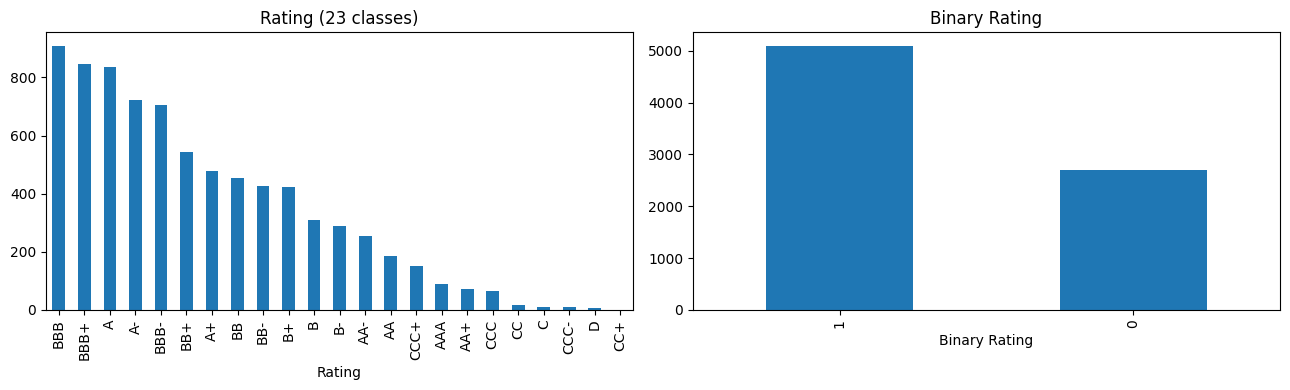

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df["Rating"].value_counts().plot(kind="bar", ax=axes[0], title="Rating (23 classes)")
df["Binary Rating"].value_counts().plot(kind="bar", ax=axes[1], title="Binary Rating")
plt.tight_layout()

**A2 判斷:**

> 不公平。`Rating` 23 個等級中最大類(BBB, 910 筆)是最小類(CC+, 1 筆)的 910 倍,且有 5 個等級樣本數不到 20 筆,
> 用 accuracy 或單純多分類決策樹/SVM 訓練,模型會直接忽略稀有等級、把大類猜好就有高分。
> 決策樹可以搭配 `class_weight="balanced"` 或事後看混淆矩陣/macro-F1 緩解,SVM 的 one-vs-rest 在極端稀有類上更難學到邊界。
> 建議先用 `Binary Rating`(投資等級 vs 非投資等級,5099:2706,約 1.9:1)做穩定的 baseline,`Rating` 多分類留到後段再挑戰。

### A3 產業別分布

`Sector` 有 12 類。之後 one-hot 時會多出 11 欄,注意會不會造成維度暴增。

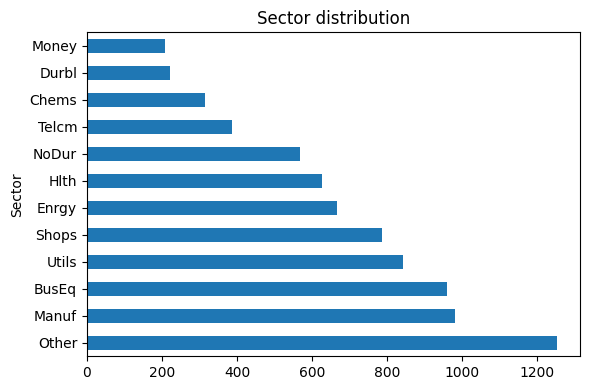

In [10]:
df["Sector"].value_counts().plot(kind="barh", figsize=(6, 4))
plt.title("Sector distribution")
plt.tight_layout()

---
# Part B — 財務比率與評等的關係

### B1 相關係數熱力圖

16 個財務比率彼此之間可能高度共線(例如 EBIT Margin 和 EBITDA Margin)。先看過再決定要不要做特徵選取(對應 04-5~04-7)。

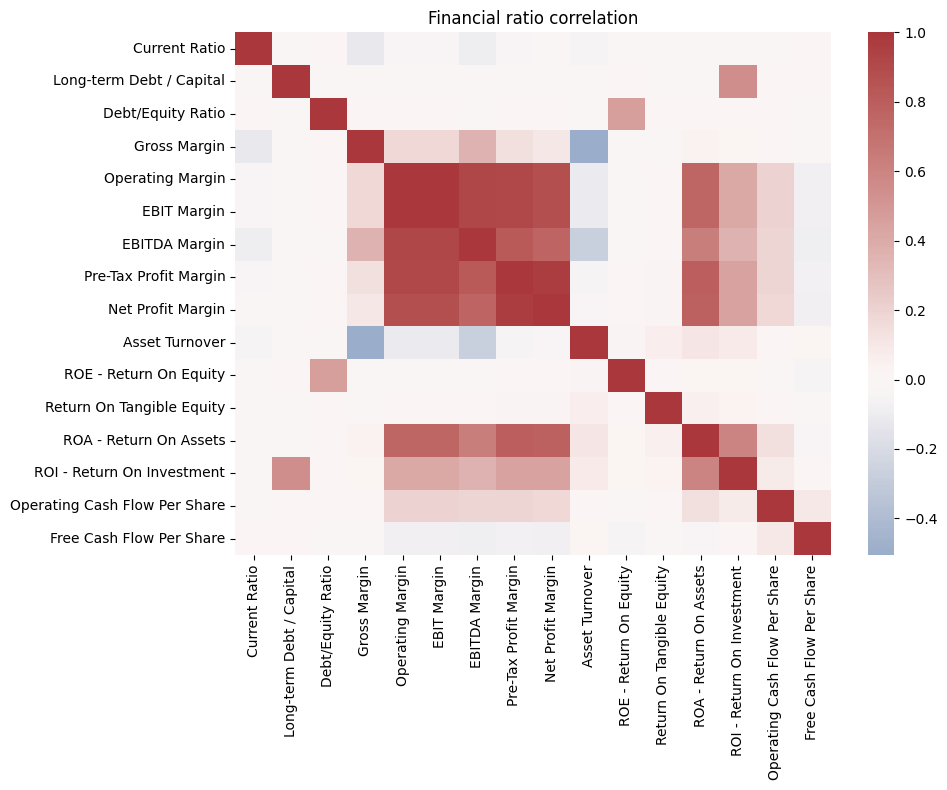

In [11]:
ratio_cols = df.select_dtypes(include="number").drop(columns=["CIK", "SIC Code", "Binary Rating"], errors="ignore")
plt.figure(figsize=(10, 8))
sns.heatmap(ratio_cols.corr(), cmap="vlag", center=0, annot=False)
plt.title("Financial ratio correlation")
plt.tight_layout()

### B2 一張條件圖:財務比率 vs 評等

**做一張以 `Binary Rating` 為條件的圖(例如 Debt/Equity Ratio 依投資等級分組的箱形圖)。**

**用一句話說出這張圖對信用風險的主張,這句話要能被推翻。**

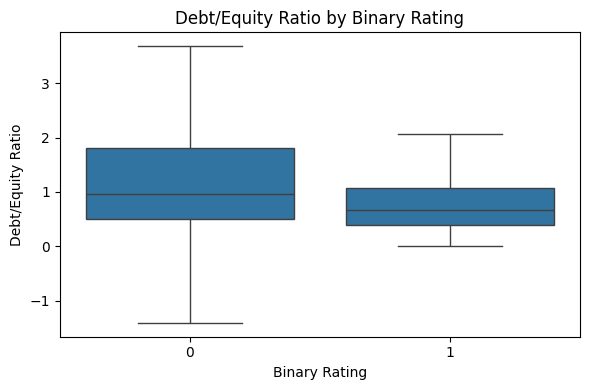

In [12]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Binary Rating", y="Debt/Equity Ratio", showfliers=False)
plt.title("Debt/Equity Ratio by Binary Rating")
plt.tight_layout()

**B2 主張:**

> 投資等級公司(Binary Rating=1)的槓桿中位數較低(Debt/Equity 中位數 0.67 vs 非投資等級的 0.96),方向符合直覺。
> 但這個結論**只在用中位數時成立**——用平均值反而是非投資等級組(0)是負的(-0.57),因為兩組都存在極端值
> (全樣本最小 -1473、最大 194.4,推測是股東權益接近或小於 0 的公司),平均值被少數異常公司拉偏。
> 這個主張可能是錯的:如果拿掉那幾家極端公司重新算,兩組差異可能縮小甚至消失,需要再檢查。

### B3 這對建模有什麼影響?

**一句話說明:B2 的發現會如何影響你接下來的前處理或選模決定(例如是否要去極端值、要不要對 Debt/Equity 取 log)。**

**B3 影響:**

> B2 顯示 Debt/Equity(以及其他比率,如 ROE、ROI 應該有同樣問題)存在極端離群值,
> 直接丟進 SVM 或邏輯迴歸這類對尺度/離群值敏感的模型前,必須先做 winsorize(如裁剪在 1~99 百分位)或用 RobustScaler 而非 StandardScaler;
> 決策樹對離群值較不敏感,可以先拿決策樹當 baseline,再决定其他模型要不要额外處理極端值。

---
## 下一步

1. 依 A2/B3 的判斷,決定用 `Binary Rating` 或 `Rating` 當目標
2. 對 `Sector` 做 one-hot(對應 04 Preprocessing)
3. 依 B1 的共線性結果,決定是否做特徵選取
4. 建 baseline:Decision Tree(05)→ SVM(09)→ Model Evaluation(06)
5. 用 t-test / Wilcoxon(20)比較模型表現是否顯著不同